<a href="https://www.kaggle.com/code/aamir28/simple-nn?scriptVersionId=321609433" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print(f"Train samples: {len(train_data)}, Test samples: {len(test_data)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 40.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.16MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.86MB/s]

Train samples: 60000, Test samples: 10000


In [3]:
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = SimpleNet().to(device)
print(model)

SimpleNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)


In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        if batch_idx % 100 == 0:
            print(f'Epoch: {epoch+1}, Batch: {batch_idx}, Loss: {loss.item():.4f}')
    
    avg_loss = running_loss / len(train_loader)
    print(f'Epoch {epoch+1} done. Avg Loss: {avg_loss:.4f}\n')

print("✅ Training complete!")

Epoch: 1, Batch: 0, Loss: 2.3013
Epoch: 1, Batch: 100, Loss: 0.4946
Epoch: 1, Batch: 200, Loss: 0.3144
Epoch: 1, Batch: 300, Loss: 0.1905
Epoch: 1, Batch: 400, Loss: 0.2566
Epoch: 1, Batch: 500, Loss: 0.0934
Epoch: 1, Batch: 600, Loss: 0.4195
Epoch: 1, Batch: 700, Loss: 0.0987
Epoch: 1, Batch: 800, Loss: 0.1194
Epoch: 1, Batch: 900, Loss: 0.1338
Epoch 1 done. Avg Loss: 0.3074

Epoch: 2, Batch: 0, Loss: 0.1239
Epoch: 2, Batch: 100, Loss: 0.1646
Epoch: 2, Batch: 200, Loss: 0.1912
Epoch: 2, Batch: 300, Loss: 0.1798
Epoch: 2, Batch: 400, Loss: 0.0780
Epoch: 2, Batch: 500, Loss: 0.0302
Epoch: 2, Batch: 600, Loss: 0.1374
Epoch: 2, Batch: 700, Loss: 0.2388
Epoch: 2, Batch: 800, Loss: 0.2242
Epoch: 2, Batch: 900, Loss: 0.1358
Epoch 2 done. Avg Loss: 0.1441

Epoch: 3, Batch: 0, Loss: 0.1163
Epoch: 3, Batch: 100, Loss: 0.0813
Epoch: 3, Batch: 200, Loss: 0.1490
Epoch: 3, Batch: 300, Loss: 0.1494
Epoch: 3, Batch: 400, Loss: 0.0116
Epoch: 3, Batch: 500, Loss: 0.0764
Epoch: 3, Batch: 600, Loss: 0.14

In [5]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

accuracy = 100 * correct / total
print(f'✅ Test Accuracy: {accuracy:.2f}%')

✅ Test Accuracy: 97.63%


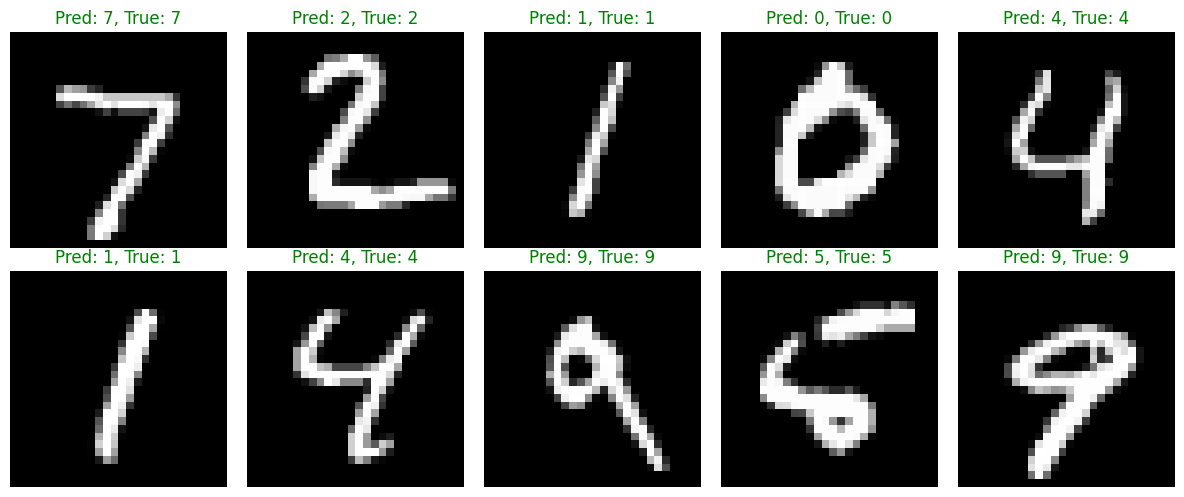

In [6]:
import matplotlib.pyplot as plt

model.eval()
test_iter = iter(test_loader)
images, labels = next(test_iter)
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Plot first 10 images with predictions
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(images[i].cpu().squeeze(), cmap='gray')
    color = 'green' if predicted[i] == labels[i] else 'red'
    axes[i].set_title(f'Pred: {predicted[i].item()}, True: {labels[i].item()}', color=color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [7]:
# Save the trained model
torch.save(model.state_dict(), '/kaggle/working/mnist_model.pth')
print("✅ Model saved to /kaggle/working/mnist_model.pth")

✅ Model saved to /kaggle/working/mnist_model.pth
